<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/12_1_open_esc_50_master.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# folder_path = '/content/drive/MyDrive/Colab Notebooks/dataset'
folder_path = '/content/drive/MyDrive/Colab Notebooks/dataset/ESC-50-master'
files = os.listdir(folder_path)
print(files)

['esc50.gif', 'README.md', 'requirements.txt', 'LICENSE', '.gitignore', 'pytest.ini', '.github', '.circleci', 'meta', 'tests', 'audio']


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/dataset/ESC-50-master/LICENSE'
with open(file_path, 'r') as file:
    content = file.read()
    print(content)

# ESC-50: Dataset for Environmental Sound Classification
# https://github.com/karoldvl/ESC-50/
# https://dx.doi.org/10.7910/DVN/YDEPUT

## Dataset license

The dataset as a whole is available under the terms of the Creative Commons
Attribution-NonCommercial license (http://creativecommons.org/licenses/by-nc/3.0/).

The ESC-10 subset is licensed as a Creative Commons Attribution 3.0 Unported
(https://creativecommons.org/licenses/by/3.0/) dataset.

## Licensing/attribution details for individual clips:

101 - Dog:
- [1-100032-A.ogg]: clip derived from rose_bark.wav (http://www.freesound.org/people/nfrae/sounds/100032/) by nfrae [CC0]
- [1-110389-A.ogg]: clip derived from animals_dog_bark_springer_spaniel_001.wav (http://www.freesound.org/people/soundscalpel.com/sounds/110389/) by soundscalpel.com [CC-BY]
- [1-30226-A.ogg]: clip derived from dogs.aiff (http://www.freesound.org/people/Heigh-hoo/sounds/30226/) by Heigh-hoo [CC0]
- [1-30344-A.ogg]: clip derived from My Dog George.wav (http:/

In [ ]:
!pip install pandas librosa matplotlib seaborn

In [ ]:
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Load the ESC-50 dataset metadata
csv_file = '/content/drive/MyDrive/Colab Notebooks/dataset/ESC-50-master/meta/esc50.csv'  # Update the path to the correct location
df = pd.read_csv(csv_file)

In [ ]:
# Display basic information about the dataset
print("Basic Info:")
print(df.info())
print("\nFirst 5 entries:")
print(df.head())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2000 non-null   object
 1   fold      2000 non-null   int64 
 2   target    2000 non-null   int64 
 3   category  2000 non-null   object
 4   esc10     2000 non-null   bool  
 5   src_file  2000 non-null   int64 
 6   take      2000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 95.8+ KB
None

First 5 entries:
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


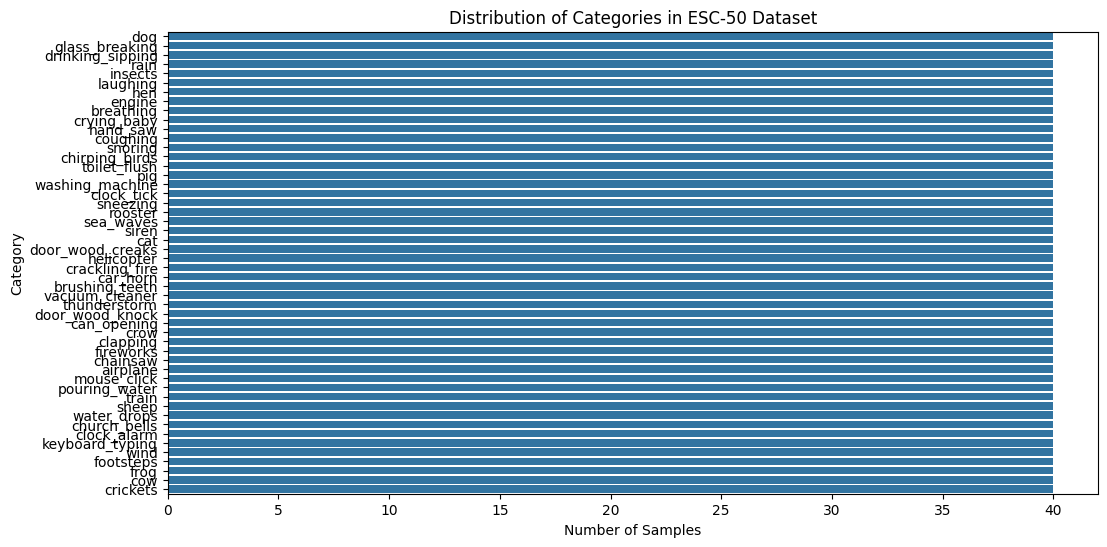

In [ ]:
# Plot the distribution of categories
plt.figure(figsize=(12, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index)
plt.title('Distribution of Categories in ESC-50 Dataset')
plt.xlabel('Number of Samples')
plt.ylabel('Category')
plt.show()

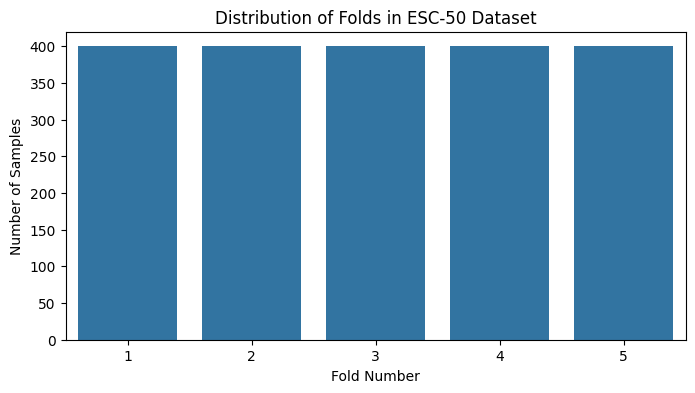

In [ ]:
# Plot the distribution of folds
plt.figure(figsize=(8, 4))
sns.countplot(x='fold', data=df)
plt.title('Distribution of Folds in ESC-50 Dataset')
plt.xlabel('Fold Number')
plt.ylabel('Number of Samples')
plt.show()

In [ ]:
# Display a random sample from each category
sample_files = df.groupby('category').apply(lambda x: x.sample(1)).reset_index(drop=True)
print("\nRandom sample from each category:")
print(sample_files[['category', 'filename']])


Random sample from each category:
            category           filename
0           airplane  5-235956-A-47.wav
1          breathing   1-36393-A-23.wav
2     brushing_teeth  5-212050-A-27.wav
3        can_opening   2-83667-A-34.wav
4           car_horn  1-254507-A-43.wav
5                cat   4-149940-B-5.wav
6           chainsaw   2-68391-B-41.wav
7     chirping_birds   1-54918-A-14.wav
8       church_bells   1-48298-A-46.wav
9           clapping  5-209989-A-22.wav
10       clock_alarm   1-34853-A-37.wav
11        clock_tick  4-198965-A-38.wav
12          coughing  5-184871-A-24.wav
13               cow   4-213915-A-3.wav
14    crackling_fire  5-193473-A-12.wav
15          crickets  3-129678-A-13.wav
16              crow   5-213836-B-9.wav
17       crying_baby  3-151080-A-20.wav
18               dog     5-9032-A-0.wav
19  door_wood_creaks  5-173568-A-33.wav
20   door_wood_knock  2-118625-A-30.wav
21  drinking_sipping   2-92978-A-29.wav
22            engine  5-240671-A-44.wav
23   

In [ ]:
import numpy as np

# Load and plot the waveform and spectrogram of a sample file
def plot_audio_sample(file_path, title=''):
    y, sr = librosa.load(file_path)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f'Waveform - {title}')

    plt.subplot(1, 2, 2)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram - {title}')
    plt.show()

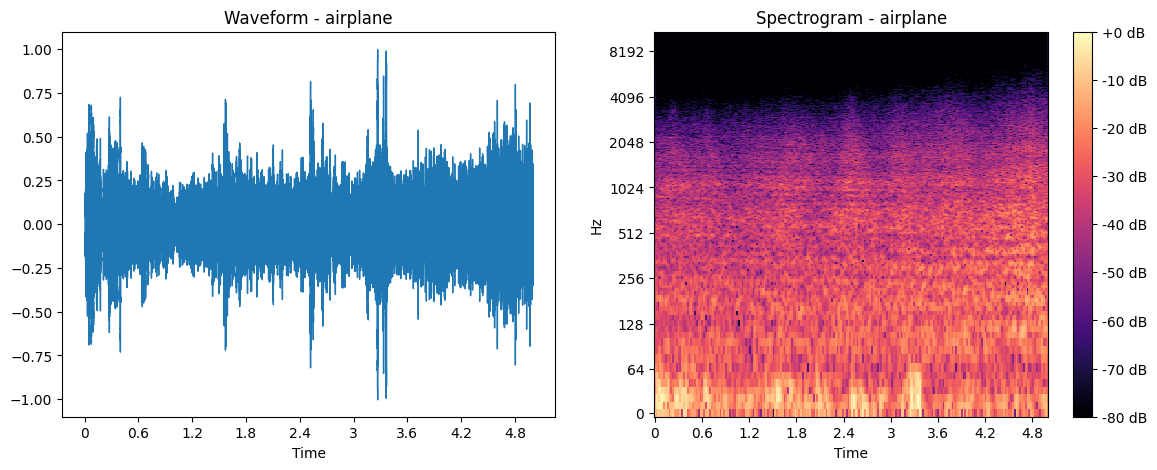

In [ ]:
example_file = os.path.join('/content/drive/MyDrive/Colab Notebooks/dataset/ESC-50-master/audio', sample_files.iloc[0]['filename'])  # Update the path accordingly
plot_audio_sample(example_file, title=sample_files.iloc[0]['category'])

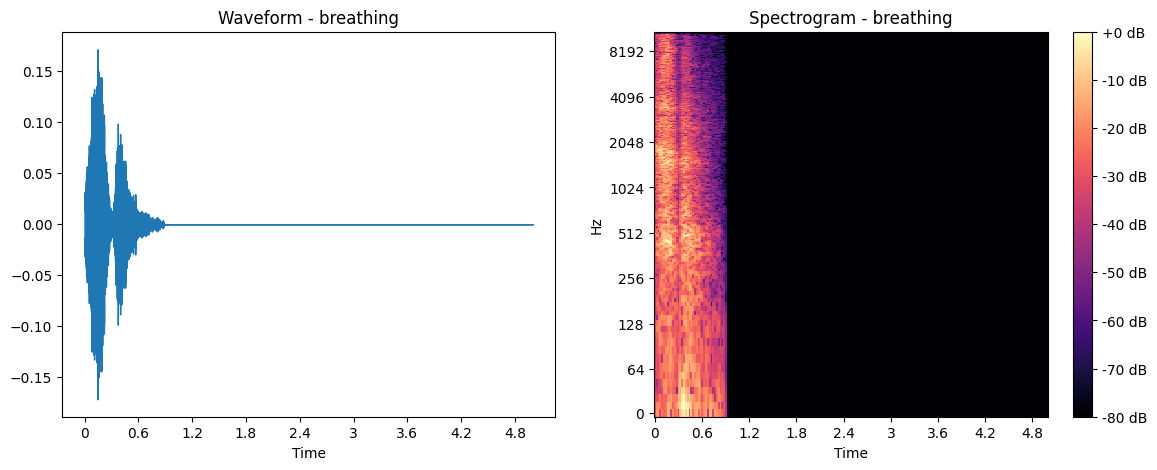

In [ ]:
# Plot an example from a random category
example_file = os.path.join('/content/drive/MyDrive/Colab Notebooks/dataset/ESC-50-master/audio', sample_files.iloc[1]['filename'])  # Update the path accordingly
plot_audio_sample(example_file, title=sample_files.iloc[1]['category'])

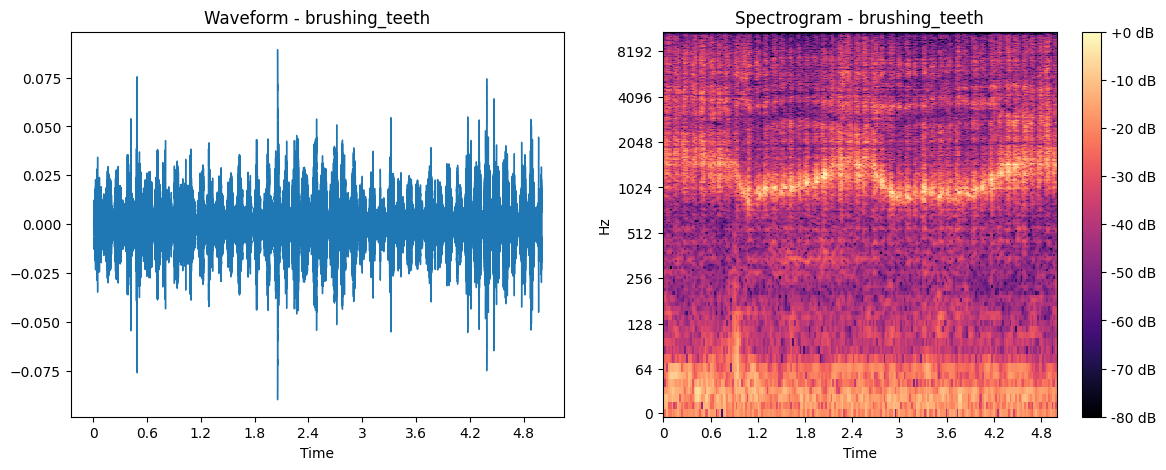

In [ ]:
# Plot an example from a random category
example_file = os.path.join('/content/drive/MyDrive/Colab Notebooks/dataset/ESC-50-master/audio', sample_files.iloc[2]['filename'])  # Update the path accordingly
plot_audio_sample(example_file, title=sample_files.iloc[2]['category'])